## Notebook created Sep 14 2025 
### to get normalized synaptic waveforms from fast and slow preferring motoneuron populations


In [1]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers import *
import pickle

In [32]:
data = pd.read_csv('normalized_currents_invertE.csv')
data.columns

Index(['Phase', 'Current', 'Normalized Current', 'Freq Bin', 'Signal Type',
       'Speed'],
      dtype='object')

In [17]:
speeds = set(data['Speed'])
speeds = ['fast', 'slow']
freqs = np.sort(list(set(data['Freq Bin'])))
currents = set(data['Signal Type'])
currents = ['excitatory', 'inhibitory']

print(set(data['Speed']))
print(speeds)

print(freqs)



{'fast', 'slow'}
['fast', 'slow']
['15–25' '25–35' '35–45' '45+']


In [24]:
def recenter_phase(df, col="Phase"):
    """
    Take a DataFrame with a Phase column in [0, 1] and remap to [-0.5, 0.5].

    - Values < 0.5 stay the same.
    - Values >= 0.5 are shifted by -1.
    """
    df = df.copy()
    phases = df[col].to_numpy()
    phases = np.where(phases >= 0.5, phases - 1.0, phases)
    df[col] = phases
    return df

data = recenter_phase(data)

In [29]:
import pandas as pd

def sort_by_phase_within_groups(
    df: pd.DataFrame,
    group_cols=('Freq Bin', 'Signal Type', 'Speed'),
    phase_col='Phase',
    preserve_group_order: bool = True
) -> pd.DataFrame:
    """
    Return a DataFrame sorted by ascending Phase within groups defined by
    (Freq Bin, Signal Type, Speed).

    Parameters
    ----------
    df : pd.DataFrame
        Your original dataframe.
    group_cols : tuple[str]
        Columns that define the groups (default: ('Freq Bin','Signal Type','Speed')).
    phase_col : str
        Name of the phase column (default: 'Phase').
    preserve_group_order : bool
        If True, keeps the first-seen order of groups as they appear in df.
        If False, groups are sorted lexicographically.

    Returns
    -------
    pd.DataFrame
        Sorted copy of df.
    """
    out = df.copy()

    if preserve_group_order:
        # Build categorical dtypes in order of first appearance for each group column
        for col in group_cols:
            if out[col].dtype.name != 'category':
                first_seen = pd.unique(out[col])
                out[col] = pd.Categorical(out[col], categories=first_seen, ordered=True)

    # Sort by groups, then by Phase ascending
    out = out.sort_values(list(group_cols) + [phase_col], ascending=True, kind='mergesort')

    # 'mergesort' is stable: it preserves the original order for ties within Phase
    return out
sorted_df = sort_by_phase_within_groups(data)
sorted_df

,Phase,Current,Normalized Current,Freq Bin,Signal Type,Speed
25,-0.49,390.861000,0.466482,35–45,Inhibitory,slow
26,-0.47,400.677600,0.495919,35–45,Inhibitory,slow
27,-0.45,406.388820,0.513968,35–45,Inhibitory,slow
28,-0.43,411.816440,0.533642,35–45,Inhibitory,slow
29,-0.41,417.561100,0.552802,35–45,Inhibitory,slow
...,...,...,...,...,...,...
770,0.41,-44.009075,0.416915,15–25,Excitatory,fast
771,0.43,-43.042824,0.404674,15–25,Excitatory,fast
772,0.45,-42.546173,0.392016,15–25,Excitatory,fast
773,0.47,-42.510433,0.384602,15–25,Excitatory,fast


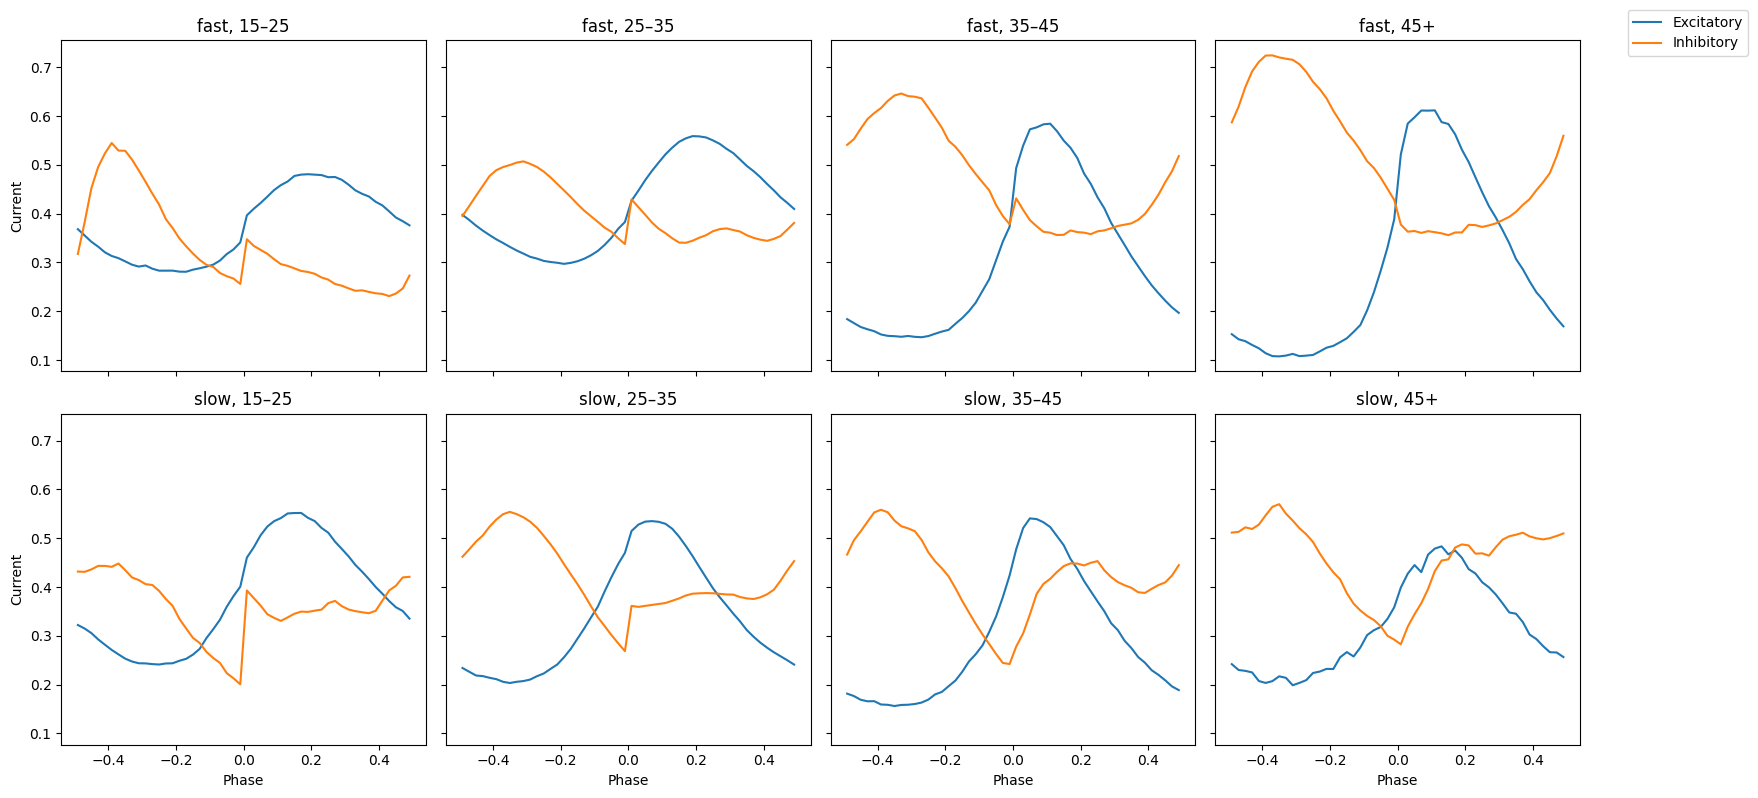

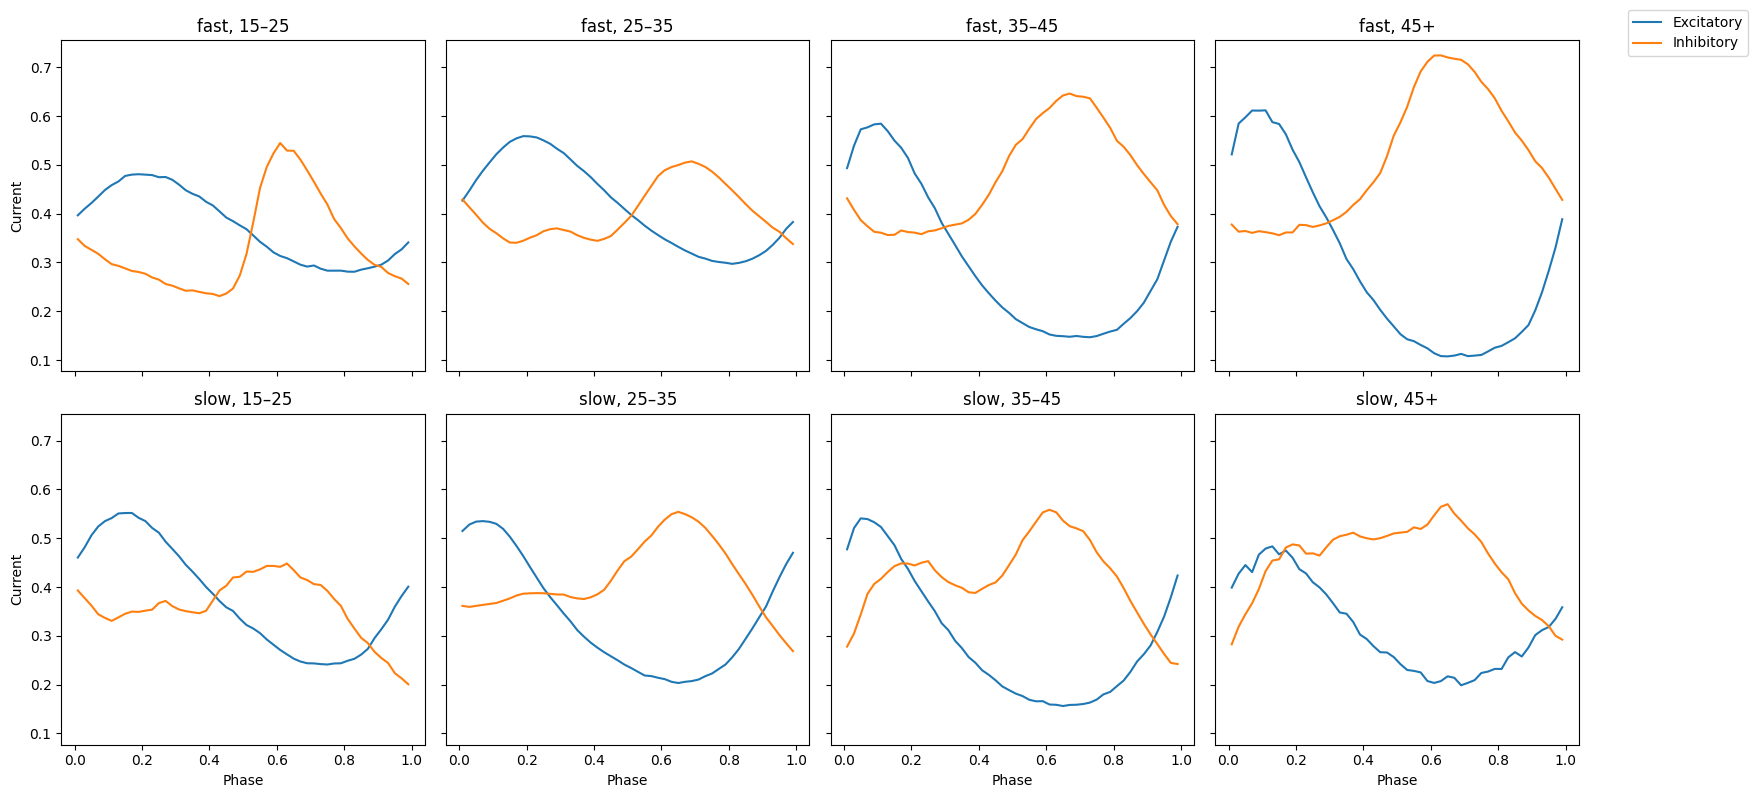

In [33]:
import matplotlib.pyplot as plt

def plot_currents_from_df(data, speeds, freq_bins, use_normalized=True):
    """
    Plot excitatory and inhibitory currents directly from the dataframe 
    on a grid of subplots.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain columns ['Phase','Current','Normalized Current',
                              'Freq Bin','Signal Type','Speed'].
    speeds : list of str
        e.g. ['fast','slow']
    freq_bins : list of str
        e.g. ['15–25','25–35','35–45','45+']
    use_normalized : bool
        If True, plot 'Normalized Current'; otherwise plot raw 'Current'.
    """
    col = 'Normalized Current' if use_normalized else 'Current'
    nrows, ncols = len(speeds), len(freq_bins)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)

    # Ensure axes is always 2D for consistent indexing
    if nrows == 1:
        axes = [axes]
    if ncols == 1:
        axes = [[ax] for ax in axes]

    for i, speed in enumerate(speeds):
        for j, freq in enumerate(freq_bins):
            ax = axes[i][j]

            # Filter excitatory and inhibitory traces
            mask_e = (data['Speed'].str.lower() == speed.lower()) & \
                     (data['Freq Bin'] == freq) & \
                     (data['Signal Type'].str.lower() == 'excitatory')
            mask_i = (data['Speed'].str.lower() == speed.lower()) & \
                     (data['Freq Bin'] == freq) & \
                     (data['Signal Type'].str.lower() == 'inhibitory')

            phases_e = data.loc[mask_e, 'Phase'].to_numpy()
            phases_i = data.loc[mask_i, 'Phase'].to_numpy()
            e_current = data.loc[mask_e, col].to_numpy()
            i_current = data.loc[mask_i, col].to_numpy()

            # Plot both traces
            ax.plot(phases_e, e_current, label="Excitatory", color="tab:blue")
            ax.plot(phases_i, i_current, label="Inhibitory", color="tab:orange")

            ax.set_title(f"{speed}, {freq}")
            if j == 0:
                ax.set_ylabel("Current")
            if i == nrows - 1:
                ax.set_xlabel("Phase")

    # Add a global legend
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.1, 1.0))
    plt.tight_layout()
    plt.show()
plot_currents_from_df(sorted_df, speeds=['fast','slow'], freq_bins=['15–25','25–35','35–45','45+'])
plot_currents_from_df(data, speeds=['fast','slow'], freq_bins=['15–25','25–35','35–45','45+'])


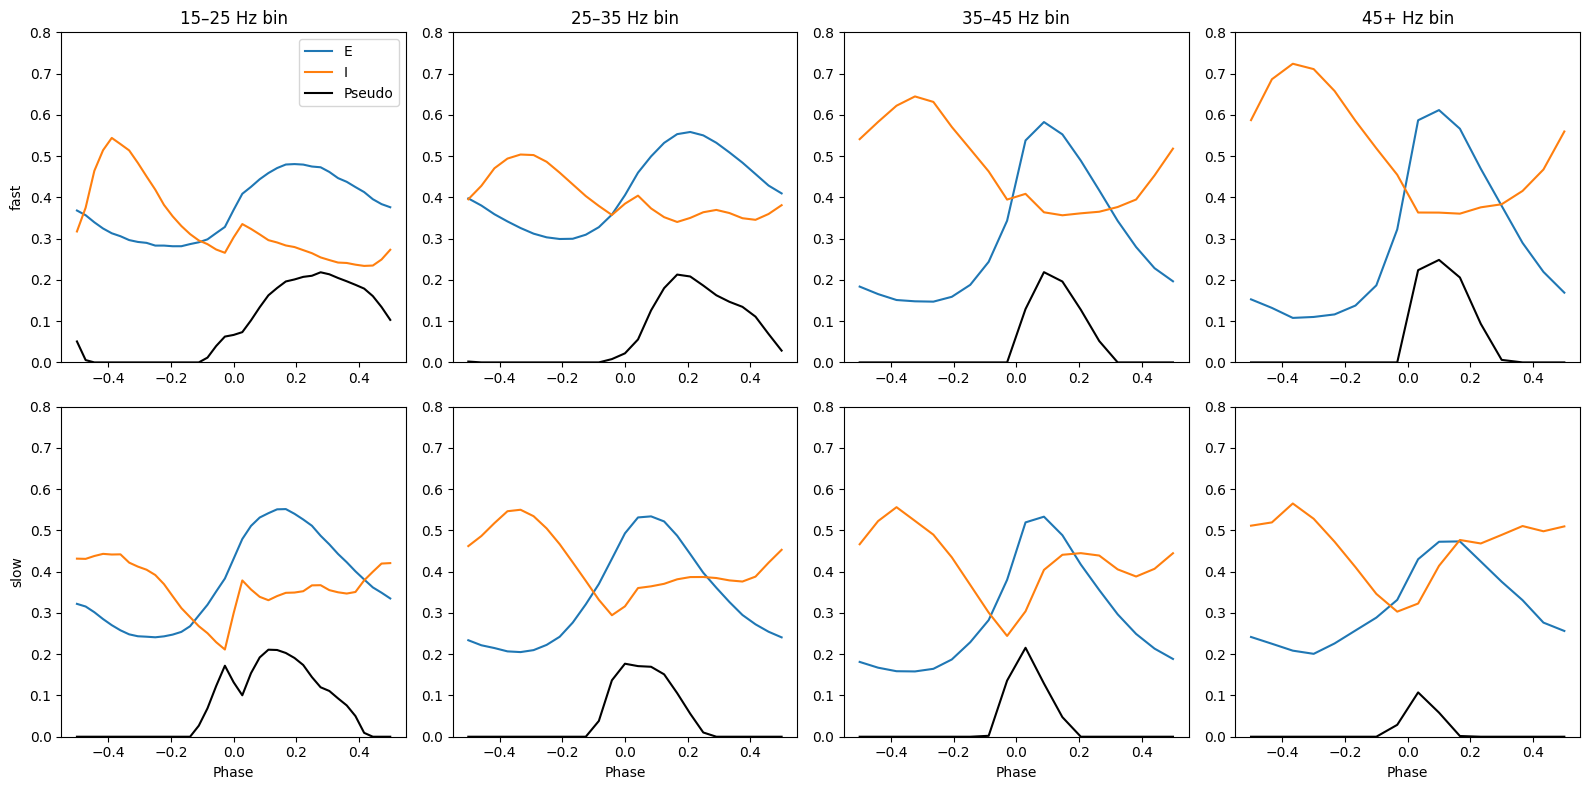

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes your DataFrame is named `data` and has columns:
# ['Phase', 'Current', 'Normalized Current', 'Freq Bin', 'Signal Type', 'Speed']
data = sort_by_phase_within_groups(data)

def _parse_freq_bin(freq_bin: str) -> int:
    """
    Convert your freq-bin labels to a representative integer frequency (Hz)
    for recruitment factors, e.g.:
      '15–25' -> 20, '25–35' -> 30, '35–45' -> 40, '45+' -> 45
    """
    s = freq_bin.replace('—', '-').replace('–', '-').strip()
    if '+' in s:
        return int(s.replace('+', '').strip())
    left, right = s.split('-')
    return int(0.5 * (float(left) + float(right)))

def get_data(speed, freq_bin, time_warped=True, time_shift=0, use_normalized=True):
    """
    Get pooled data (no cell category) for a particular speed and frequency bin.

    Parameters
    --
    speed : 'fast' or 'slow'
    freq_bin : one of ['15–25','25–35','35–45','45+'] (any en dash/ hyphen variants OK)
    time_warped : if False, resample proportionally to the representative frequency
    time_shift : integer phase-bin shift (100 phase steps == one period)
    use_normalized : if True use 'Normalized Current', else use raw 'Current'

    Returns
    --
    phases : 1D array of phases (-0.5 < phase < 0.5)
    e_current, i_current : 1D arrays of excitatory and inhibitory currents
    pseudo_output : rectified E-I difference, optionally phase-shifted
    """
    freq_bin_norm = freq_bin.replace('—', '–')  # normalize label
    col = 'Normalized Current' if use_normalized else 'Current'

    mask_e = (
        (data['Speed'].str.lower() == speed.lower()) &
        (data['Freq Bin'] == freq_bin_norm) &
        (data['Signal Type'].str.lower() == 'excitatory')
    )
    mask_i = (
        (data['Speed'].str.lower() == speed.lower()) &
        (data['Freq Bin'] == freq_bin_norm) &
        (data['Signal Type'].str.lower() == 'inhibitory')
    )

    # Pull phase/current (assumes rows are aligned within each (speed,freq,signal) slice)
    phases = data.loc[mask_e, 'Phase'].to_numpy()
    e_current = data.loc[mask_e, col].to_numpy()
    i_current = data.loc[mask_i, col].to_numpy()

    # Safety: if inhibitory slice length differs, align by common length
    n = min(len(phases), len(e_current), len(i_current))
    phases, e_current, i_current = phases[:n], e_current[:n], i_current[:n]

    # Pseudo-output: half-wave rectified difference
    diff = e_current - i_current
    pseudo_output = 0.5 * (1 + np.sign(diff)) * diff
    pseudo_output = np.roll(pseudo_output, time_shift)

    if not time_warped:
        # resample proportionally to representative frequency (relative to 15 Hz baseline)
        f = _parse_freq_bin(freq_bin)
        n_steps = int(len(phases) * 15 / max(f, 1))
        phases_interp = np.linspace(-0.5, 0.5, n_steps)
        e_current = np.interp(phases_interp, phases, e_current)
        i_current = np.interp(phases_interp, phases, i_current)
        pseudo_output = np.interp(phases_interp, phases, pseudo_output)
        phases = phases_interp

    return phases, e_current, i_current, pseudo_output

def get_e_currents(freq_bin):
    """
    Returns n_timesteps x 2 matrix of E currents for [fast, slow] (no cell categories).
    """
    _, e_fast, _, _ = get_data('fast', freq_bin, time_warped=False)
    _, e_slow, _, _ = get_data('slow', freq_bin, time_warped=False)
    # Align lengths just in case
    m = min(len(e_fast), len(e_slow))
    return np.vstack([e_fast[:m], e_slow[:m]]).T  # shape: (T, 2)

def get_i_currents(freq_bin):
    """
    Returns n_timesteps x 2 matrix of I currents for [fast, slow] (no cell categories).
    """
    _, _, i_fast, _ = get_data('fast', freq_bin, time_warped=False)
    _, _, i_slow, _ = get_data('slow', freq_bin, time_warped=False)
    m = min(len(i_fast), len(i_slow))
    return np.vstack([i_fast[:m], i_slow[:m]]).T  # shape: (T, 2)

def get_pseudo_outputs(freq_bin, n_lags=1, tonic_only=False):
    """
    Returns a (n_timesteps) x (outputs) matrix.
    With no cell categories, we use just [fast, slow] per lag.

    Ordering per lag (phase=0 block):
      fast (lag 1), slow (lag 1), fast (lag 2), slow (lag 2), ..., fast (lag n), slow (lag n)
    Then a phase-flipped copy (commissural inhibition analog).
    Finally, add two tonic channels [tonic fast, tonic slow].

    If tonic_only==True, dynamic channels are zeroed out but tonic channels remain.
    """
    f = _parse_freq_bin(freq_bin)
    # Example recruit factors that grow with frequency (tweak as you like)
    fast_recruit = (f - 15) / (45 - 15)
    slow_recruit = (45 - f) / (45 - 15)
    fast_recruit = np.clip(fast_recruit, 0, 1)
    slow_recruit = np.clip(slow_recruit, 0, 1)

    # Build stacked pseudo outputs for requested lags
    for n in range(n_lags):
        shift = -3 * n_lags  # keep your original shift pattern
        _, _, _, po_fast = get_data('fast', freq_bin, time_warped=False, time_shift=shift)
        _, _, _, po_slow = get_data('slow', freq_bin, time_warped=False, time_shift=shift)

        # First iteration: initialize; subsequent: vstack
        if n == 0:
            pseudo = np.vstack([fast_recruit * po_fast, slow_recruit * po_slow])
        else:
            pseudo = np.vstack([pseudo, fast_recruit * po_fast, slow_recruit * po_slow])

    # Add phase-opposed copy
    half = pseudo.shape[1] // 2
    pseudo = np.vstack([pseudo, np.roll(pseudo, half, axis=1)])

    # Add tonic channels (two rows)
    T = pseudo.shape[1]
    tonic = np.vstack([fast_recruit * np.ones(T), slow_recruit * np.ones(T)])

    if tonic_only:
        pseudo = np.vstack([np.zeros_like(pseudo), tonic])
    else:
        pseudo = np.vstack([pseudo, tonic])

    return pseudo.T  # (T, n_channels)

# --- Example plotting (no cell loop) ---
speeds = ['fast','slow']
freqs = ['15–25','25–35','35–45','45+']
currents = ['E', 'I', 'Pseudo']
plt.figure(figsize=(16,8))
idx = 1
for j, speed in enumerate(speeds):
    for k, freq in enumerate(freqs):
        plt.subplot(2, 4, idx); idx += 1
        plt.ylim(0, 0.8)
        phases, e_current, i_current, pseudo_output = get_data(speed, freq, time_warped=False)
        plt.plot(phases, e_current, label='E')
        plt.plot(phases, i_current, label='I')
        plt.plot(phases, pseudo_output, c='k', label='Pseudo')
        if j == 0: plt.title(f'{freq} Hz bin')
        if k == 0: plt.ylabel(speed)
        if j == 1: plt.xlabel('Phase')
        if idx == 2: plt.legend()
plt.tight_layout()
plt.show()
